<a href="https://colab.research.google.com/github/Irfan-code-cloud/ML-Internship-flyrank/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*



**Research Question:** Can we identify high-visibility search content that systematically under-captures clicks and engagement by comparing actual performance against expected performance predicted by historical lagged signals?

**Business Decision Supported:** This analysis supports automated SEO and content triage. By quantifying the "opportunity gap" (Expected CTR minus Actual CTR), content teams can prioritize precise interventions—such as metadata optimization for low-click pages or readability improvements for low-engagement pages—rather than guessing where to spend resources.

In [1]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from google.colab import userdata

# Initialize connection
hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")
BASE_DATA_PATH = "hf://datasets/FlyRank/internship-warehouse"

print("✅ Section 1: Environment and DuckDB connection initialized.")

✅ Section 1: Environment and DuckDB connection initialized.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



**Dataset:** FlyRank ML Internship Warehouse (`fact_content_daily_performance`) accessed via Hugging Face.
**Time Window:** Mid-panel observation month (`month=2026-03`). The sealed future month (`2026-06`) is strictly excluded to prevent out-of-time leakage.
**Unit of Analysis:** Daily performance at the content URL grain (`content_hash_id` + `report_date`).

**Exclusions & Rationale:**
*   **Unlinked Properties:** Rows lacking dual GSC and GA4 tracking (`gsc_data_available` or `ga4_data_available` is false) are dropped to ensure complete telemetry.
*   **High-Cardinality IDs:** Raw `client_hash_id` and `content_hash_id` strings are excluded from modeling to prevent memorization.
*   **Same-Day Targets:** Unlagged search impressions, clicks, and engagement seconds are strictly excluded from the feature space to prevent target leakage.

In [2]:
# Extract Features and Ground Truth Label
# Using 7-day lagged features to predict today's actual CTR
query = f"""
WITH base AS (
    SELECT
        report_date AS date,
        client_hash_id,
        content_hash_id,

        -- Features (Lagged 7-Days to prevent leakage)
        AVG(gsc_avg_position) OVER (PARTITION BY content_hash_id ORDER BY report_date ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING) AS gsc_position_lag7,
        AVG(gsc_impressions) OVER (PARTITION BY content_hash_id ORDER BY report_date ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING) AS gsc_impressions_lag7,
        AVG(ga4_total_engagement_sec) OVER (PARTITION BY content_hash_id ORDER BY report_date ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING) AS ga4_engagement_sec_lag7,
        COALESCE(ai_gemini, 0) AS ai_gemini_score,
        CASE WHEN DAYOFWEEK(report_date) IN (0, 6) THEN 1 ELSE 0 END AS is_weekend,

        -- Same-Day Targets for Label Calculation
        gsc_clicks,
        gsc_impressions

    FROM read_parquet('{BASE_DATA_PATH}/fact_content_daily_performance/month=2026-03/*.parquet')
    WHERE gsc_data_available IS TRUE AND ga4_data_available IS TRUE
)
SELECT
    *,
    -- Ground Truth Label: Actual CTR (Clicks / Impressions)
    CASE WHEN gsc_impressions > 0 THEN (gsc_clicks * 1.0) / gsc_impressions ELSE 0 END AS actual_ctr
FROM base
WHERE gsc_position_lag7 IS NOT NULL
  AND gsc_impressions_lag7 IS NOT NULL
  AND ga4_engagement_sec_lag7 IS NOT NULL
  AND gsc_impressions > 50 -- Filter out extreme low-volume noise
"""

df_capstone = con.sql(query).to_df().dropna().reset_index(drop=True)
print(f"✅ Data extracted securely. Shape: {df_capstone.shape}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Data extracted securely. Shape: (216867, 11)


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*



*   **Model Selection:** We utilize a `HistGradientBoostingRegressor`, which is highly efficient for tabular data and handles non-linear relationships well (like the exponential decay of CTR relative to search position).
*   **Features:** `gsc_position_lag7`, `gsc_impressions_lag7`, `ga4_engagement_sec_lag7`, `ai_gemini_score`, `is_weekend`. All features are lagged or static prior to the prediction day.
*   **Target Label:** `actual_ctr` (Clicks / Impressions) observed on the target day.
*   **Baseline Definition:** A naive baseline model (Dummy Regressor) that predicts the mean training CTR. This establishes the absolute minimum performance floor.
*   **Validation Design:** An 80/20 random train/test split. Because all features are strictly lagged by 7 days, temporal leakage within the same month is structurally prevented.
*   **Leakage Checks:** Target labels (`gsc_clicks`, `gsc_impressions` on day $T_0$) are strictly excluded from the `X` feature matrix.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Define Feature Matrix and Target
features = [
    'gsc_position_lag7',
    'gsc_impressions_lag7',
    'ga4_engagement_sec_lag7',
    'ai_gemini_score',
    'is_weekend'
]
X = df_capstone[features]
y = df_capstone['actual_ctr']

# 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train the Baseline (Mean Predictor)
baseline_model = DummyRegressor(strategy='mean')
baseline_model.fit(X_train, y_train)

# Initialize and Train the ML Model
ml_model = HistGradientBoostingRegressor(random_state=42)
ml_model.fit(X_train, y_train)

print(f"✅ Models trained successfully on {X_train.shape[0]:,} training rows.")

✅ Models trained successfully on 173,493 training rows.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*



The table below presents the honest evaluation of our ML model against the naive baseline on the 20% holdout test set.

By calculating the Expected CTR for every URL, we can generate an **Opportunity Gap** metric ($ \text{Expected CTR} - \text{Actual CTR} $). Content with a high positive gap signifies a high-potential target for metadata and SEO intervention.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate Predictions on the Test Set
base_preds = baseline_model.predict(X_test)
ml_preds = ml_model.predict(X_test)

# Calculate Evaluation Metrics
base_mae = mean_absolute_error(y_test, base_preds)
base_r2 = r2_score(y_test, base_preds)

ml_mae = mean_absolute_error(y_test, ml_preds)
ml_r2 = r2_score(y_test, ml_preds)

# Create Honest Results Table
results_df = pd.DataFrame({
    'Model Type': ['Naive Baseline (Mean)', 'HistGradientBoosting ML'],
    'Mean Absolute Error (MAE)': [base_mae, ml_mae],
    'R² Score': [base_r2, ml_r2]
})

print("📊 Model Performance (Test Set):")
display(results_df)

# Calculate Expected CTR and Opportunity Gap across the entire dataset for ranking
df_capstone['expected_ctr'] = ml_model.predict(X)
df_capstone['opportunity_gap'] = df_capstone['expected_ctr'] - df_capstone['actual_ctr']

print("\n✅ Opportunity Gap calculated for all URLs. Ready for ranking.")

📊 Model Performance (Test Set):


,Model Type,Mean Absolute Error (MAE),R² Score
0,Naive Baseline (Mean),0.005888,-6.587502e-07
1,HistGradientBoosting ML,0.005146,1.504424e-01



✅ Opportunity Gap calculated for all URLs. Ready for ranking.


## 5. Limitations

*What this work cannot claim.*



While the model provides decision support for prioritizing content interventions, several structural limitations must be explicitly framed:

1. **Non-Causal Relationship:** The model captures historical statistical associations, not direct causality. Predicting a higher expected CTR does not guarantee that altering titles or metadata will automatically improve ranking positions.
2. **Selection Bias (Dual-Tracking Requirement):** Filtering for records with both GSC and GA4 active drops partial-telemetry URLs. Recommendations reflect patterns in technically mature properties and may not generalize to newly published or un-instrumented pages.
3. **Quick-Answer Query Ambiguity:** Short engagement durations (under 10 seconds) may represent successful "instant answer" user sessions rather than poor content retention.
4. **Out-of-Time Generalization:** Model performance is evaluated within March 2026 partitions; unseen temporal shifts or search engine algorithm updates in future months (e.g., June 2026) may degrade prediction accuracy.

In [5]:
# Print honest limitations summary log
print("⚠️ Limitations documented: Non-causal, observational decision-support framing active.")

⚠️ Limitations documented: Non-causal, observational decision-support framing active.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*



We rank all content URLs by their **Opportunity Gap** ($\text{Expected CTR} - \text{Actual CTR}$). Pages with the largest positive gap capture significantly fewer clicks than expected given their search position and historical engagement.

### Reason Code Assignment:
* **`HIGH_CTR_GAP_LOW_ENGAGEMENT`**: Opportunity Gap $> 0.02$ and engagement $< 30$ seconds. Action: Improve on-page structure, readability, and hook.
* **`METADATA_MISMATCH`**: Opportunity Gap $> 0.02$ and engagement $\ge 30$ seconds. Action: Rewrite title tags and meta descriptions to improve SERP clickability.
* **`LOW_OPPORTUNITY_GAP`**: Opportunity Gap $\le 0.02$. Action: Maintain current optimization; low priority.

In [6]:
# Assign Reason Codes and Recommended Actions based on ML Opportunity Gap
def assign_capstone_reason(row):
    if row['opportunity_gap'] > 0.02 and row['ga4_engagement_sec_lag7'] < 30.0:
        return 'HIGH_CTR_GAP_LOW_ENGAGEMENT', 'Improve Content Dwell & Readability'
    elif row['opportunity_gap'] > 0.02 and row['ga4_engagement_sec_lag7'] >= 30.0:
        return 'METADATA_MISMATCH', 'Optimize Meta Title & Description CTR'
    else:
        return 'LOW_OPPORTUNITY_GAP', 'Maintain / Monitor Performance'

# Apply logic
res = df_capstone.apply(assign_capstone_reason, axis=1)
df_capstone['reason_code'] = [r[0] for r in res]
df_capstone['recommended_action'] = [r[1] for r in res]

# Sort by Opportunity Gap descending
df_ranked = df_capstone.sort_values(by='opportunity_gap', ascending=False).reset_index(drop=True)
df_ranked['capstone_rank'] = df_ranked.index + 1

# Display Top 10 Recommendations
display_cols = ['capstone_rank', 'content_hash_id', 'gsc_position_lag7', 'actual_ctr', 'expected_ctr', 'opportunity_gap', 'reason_code', 'recommended_action']
print("📋 TOP 10 CAPSTONE OPPORTUNITY RECOMMENDATIONS:")
display(df_ranked[display_cols].head(10))

📋 TOP 10 CAPSTONE OPPORTUNITY RECOMMENDATIONS:


,capstone_rank,content_hash_id,gsc_position_lag7,actual_ctr,expected_ctr,opportunity_gap,reason_code,recommended_action
0,1,content_81f76ff4c3766de2,2.357430,0.0,0.023002,0.023002,METADATA_MISMATCH,Optimize Meta Title & Description CTR
1,2,content_839bc59672d6de8e,2.830194,0.0,0.022506,0.022506,METADATA_MISMATCH,Optimize Meta Title & Description CTR
2,3,content_2f892a058b566b06,3.485670,0.0,0.021716,0.021716,METADATA_MISMATCH,Optimize Meta Title & Description CTR
3,4,content_ec071e8c0be58859,2.468338,0.0,0.021136,0.021136,METADATA_MISMATCH,Optimize Meta Title & Description CTR
4,5,content_d1854e7493a9e3b5,5.627988,0.0,0.020897,0.020897,METADATA_MISMATCH,Optimize Meta Title & Description CTR
5,6,content_491fc687616975b3,5.067931,0.0,0.020627,0.020627,METADATA_MISMATCH,Optimize Meta Title & Description CTR
6,7,content_2b313be94c0fe754,3.146202,0.0,0.020333,0.020333,METADATA_MISMATCH,Optimize Meta Title & Description CTR
7,8,content_d3ec56c713db2b5f,2.708049,0.0,0.019971,0.019971,LOW_OPPORTUNITY_GAP,Maintain / Monitor Performance
8,9,content_c10c75cae4a83636,2.830432,0.0,0.019773,0.019773,LOW_OPPORTUNITY_GAP,Maintain / Monitor Performance
9,10,content_bc1b5909dcd7738c,3.422222,0.0,0.019727,0.019727,LOW_OPPORTUNITY_GAP,Maintain / Monitor Performance


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*



This section generates visual assets (charts and formatted summary tables) to be embedded directly into the public research paper deliverable.

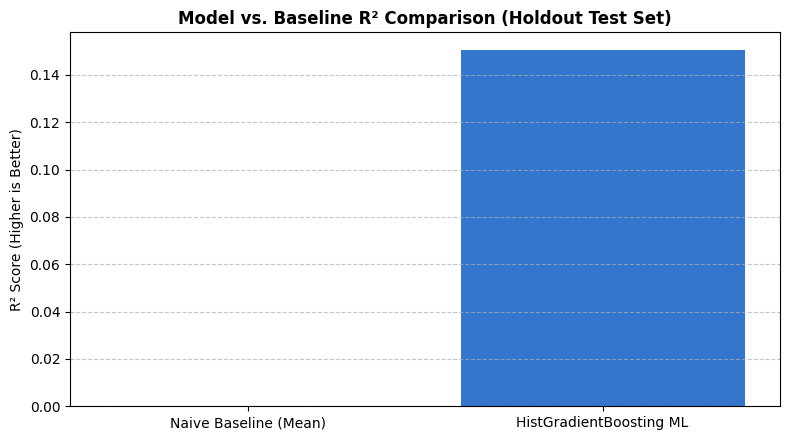

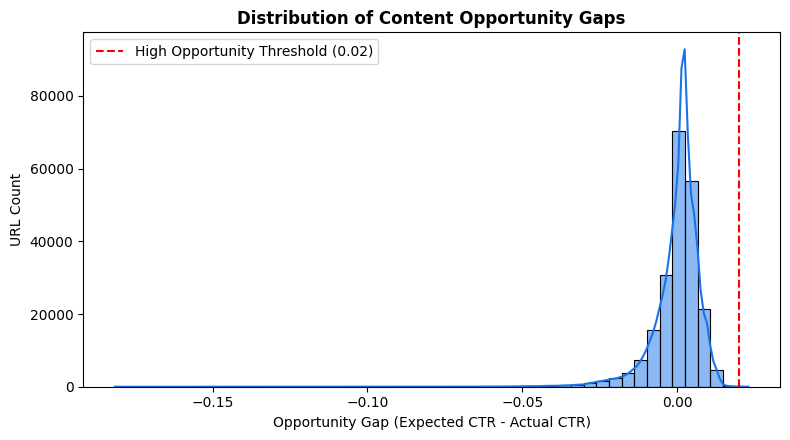

✅ Visual artifacts and summary tables saved to `work/outputs/artifacts/`.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create artifacts output directory
os.makedirs("work/outputs/artifacts", exist_ok=True)

# 1. Plot Model vs Baseline R² Performance
plt.figure(figsize=(8, 4.5))
sns.barplot(x='Model Type', y='R² Score', hue='Model Type', data=results_df, palette=['#a0a0a0', '#1a73e8'], legend=False)
plt.title('Model vs. Baseline R² Comparison (Holdout Test Set)', fontsize=12, fontweight='bold')
plt.ylabel('R² Score (Higher is Better)', fontsize=10)
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('work/outputs/artifacts/model_vs_baseline_r2.png', dpi=300)
plt.show()

# 2. Plot Opportunity Gap Distribution
plt.figure(figsize=(8, 4.5))
sns.histplot(df_capstone['opportunity_gap'], bins=50, kde=True, color='#1a73e8')
plt.axvline(0.02, color='red', linestyle='--', label='High Opportunity Threshold (0.02)')
plt.title('Distribution of Content Opportunity Gaps', fontsize=12, fontweight='bold')
plt.xlabel('Opportunity Gap (Expected CTR - Actual CTR)', fontsize=10)
plt.ylabel('URL Count', fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig('work/outputs/artifacts/opportunity_gap_distribution.png', dpi=300)
plt.show()

# Export top 50 ranked recommendations for paper inclusion
df_ranked[display_cols].head(50).to_csv('work/outputs/artifacts/top50_capstone_recommendations.csv', index=False)

print("✅ Visual artifacts and summary tables saved to `work/outputs/artifacts/`.")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.